Mounted at /content/drive
🌽 CORN — PHASE 2: MODEL TRAINING

Preprocessed data:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/3rd Preprocessing/Corn/corn_processed_data.npz

Model output folder:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/6th Trained_Model/Corn

LOADING PREPROCESSED DATA

X_train: (1256, 224, 224, 3)
y_train: (1256,)

X_val: (269, 224, 224, 3)
y_val: (269,)

X_test: (270, 224, 224, 3)
y_test: (270,)

Class mapping:
0 -> Healthy
1 -> Common_Rust
2 -> Northern_Leaf_Blight

PASS: Image dimensions verified
PASS: RGB format verified
PASS: uint8 data verified
PASS: Train / Validation / Test arrays loaded

TRAINING CLASS DISTRIBUTION
0 -> Healthy: 416
1 -> Common_Rust: 420
2 -> Northern_Leaf_Blight: 420

Random seed: 42

BUILDING MOBILENETV2 MODEL
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Model created successfully.

Trainable parameters: 3843
Total parameters: 2261827



Model summary saved:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/6th Trained_Model/Corn/corn_model_summary.txt

STAGE 1 — TRANSFER LEARNING
Epoch 1/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5331 - loss: 1.0547
Epoch 1: val_accuracy improved from None to 0.82900, saving model to /content/drive/MyDrive/Plant Disease Detection (Computer Vision)/6th Trained_Model/Corn/corn_mobilenetv2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Plant Disease Detection (Computer Vision)/6th Trained_Model/Corn/corn_mobilenetv2_best.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.6409 - loss: 0.8298 - val_accuracy: 0.8290 - val_loss: 0.4294 - learning_rate: 0.0010
Epoch 2/12
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7714 - loss: 0.5479
Epoch 2: val_accuracy improved from 0.82900 to 0.89963, saving model to /content/drive/MyDrive/Plant Disease Detection (Computer Vision)/6th Trained_Model/Corn/corn_mobilenetv2_best.keras

Epoch 2:

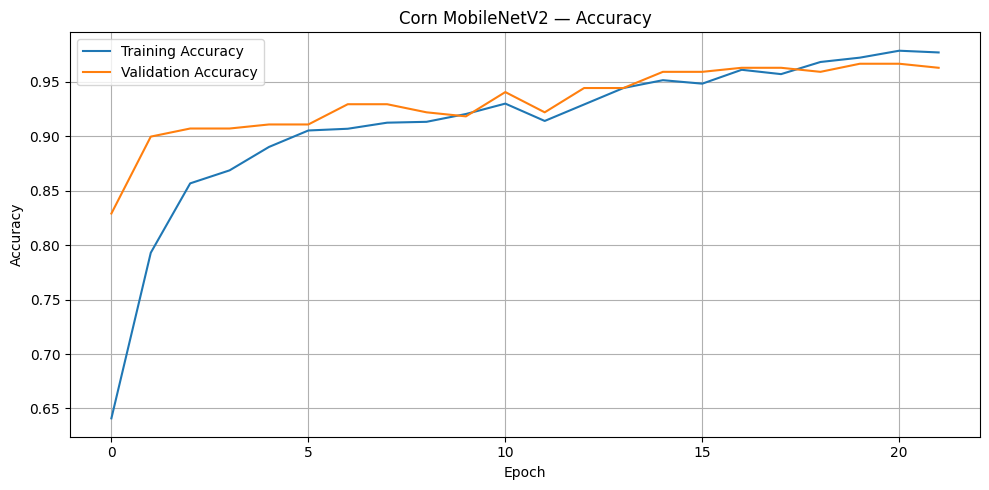

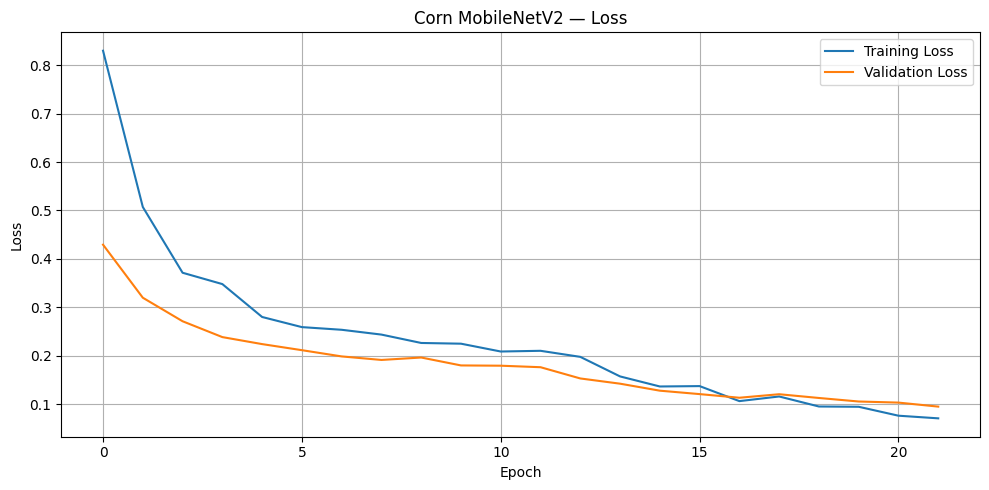


Training configuration saved:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/6th Trained_Model/Corn/corn_training_config.json

🌽 CORN — MODEL TRAINING FINAL AUDIT
PASS | Training data loaded
PASS | Validation data loaded
PASS | Test data not used for training
PASS | MobileNetV2 ImageNet model
PASS | Best model saved
PASS | Final model saved
PASS | Training history saved
PASS | Model summary saved
PASS | Training configuration saved

🎉 CORN — MODEL TRAINING: PASS

Best validation accuracy: 96.65%

Best model:
/content/drive/MyDrive/Plant Disease Detection (Computer Vision)/6th Trained_Model/Corn/corn_mobilenetv2_best.keras

Next step:
Model Evaluation → Test Accuracy → Precision → Recall → F1-score → Confusion Matrix → Per-class performance


In [1]:
# ==============================================================================================
# 🌽 CORN — PHASE 2: MODEL TRAINING
# ==============================================================================================
# Model: MobileNetV2 Transfer Learning
#
# Workflow:
#   Preprocessed NPZ
#        ↓
#   Train data only
#        ↓
#   MobileNetV2 Transfer Learning
#        ↓
#   Validation-based model selection
#        ↓
#   Fine-tuning
#        ↓
#   Best Model
#        ↓
#   6th Trained_Model/Corn/
#
# IMPORTANT:
# Test data is NOT used during training.
# Test data will be used later in the separate Evaluation cell.
# ==============================================================================================

import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from pathlib import Path

from tensorflow.keras import layers
from tensorflow.keras import Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# ==============================================================================================
# 1. GOOGLE DRIVE
# ==============================================================================================

from google.colab import drive

drive.mount('/content/drive')

print("=" * 90)
print("🌽 CORN — PHASE 2: MODEL TRAINING")
print("=" * 90)

# ==============================================================================================
# 2. PATHS
# ==============================================================================================

DRIVE_ROOT = Path(
    "/content/drive/MyDrive/Plant Disease Detection (Computer Vision)"
)

PREPROCESS_ROOT = (
    DRIVE_ROOT /
    "3rd Preprocessing" /
    "Corn"
)

MODEL_ROOT = (
    DRIVE_ROOT /
    "6th Trained_Model" /
    "Corn"
)

MODEL_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

NPZ_PATH = (
    PREPROCESS_ROOT /
    "corn_processed_data.npz"
)

CLASS_MAPPING_PATH = (
    PREPROCESS_ROOT /
    "corn_class_mapping.csv"
)

BEST_MODEL_PATH = (
    MODEL_ROOT /
    "corn_mobilenetv2_best.keras"
)

FINAL_MODEL_PATH = (
    MODEL_ROOT /
    "corn_mobilenetv2_final.keras"
)

HISTORY_PATH = (
    MODEL_ROOT /
    "corn_training_history.csv"
)

SUMMARY_PATH = (
    MODEL_ROOT /
    "corn_model_summary.txt"
)

CONFIG_PATH = (
    MODEL_ROOT /
    "corn_training_config.json"
)

print("\nPreprocessed data:")
print(NPZ_PATH)

print("\nModel output folder:")
print(MODEL_ROOT)

# ==============================================================================================
# 3. VERIFY PREPROCESSED DATA
# ==============================================================================================

if not NPZ_PATH.exists():

    raise RuntimeError(
        "\nSTOP: Preprocessed Corn dataset not found.\n"
        f"Expected:\n{NPZ_PATH}"
    )

print("\n" + "=" * 90)
print("LOADING PREPROCESSED DATA")
print("=" * 90)

data = np.load(
    NPZ_PATH
)

X_train = data["X_train"]
y_train = data["y_train"]

X_val = data["X_val"]
y_val = data["y_val"]

X_test = data["X_test"]
y_test = data["y_test"]

print("\nX_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nX_val:", X_val.shape)
print("y_val:", y_val.shape)

print("\nX_test:", X_test.shape)
print("y_test:", y_test.shape)

# ==============================================================================================
# 4. CLASS MAPPING
# ==============================================================================================

FINAL_CLASSES = [
    "Healthy",
    "Common_Rust",
    "Northern_Leaf_Blight"
]

NUM_CLASSES = len(FINAL_CLASSES)

print("\nClass mapping:")

for index, class_name in enumerate(FINAL_CLASSES):

    print(
        f"{index} -> {class_name}"
    )

# ==============================================================================================
# 5. BASIC DATA VALIDATION
# ==============================================================================================

if X_train.shape[1:] != (224, 224, 3):

    raise RuntimeError(
        f"STOP: Unexpected training image shape: "
        f"{X_train.shape[1:]}"
    )

if X_val.shape[1:] != (224, 224, 3):

    raise RuntimeError(
        f"STOP: Unexpected validation image shape: "
        f"{X_val.shape[1:]}"
    )

if X_test.shape[1:] != (224, 224, 3):

    raise RuntimeError(
        f"STOP: Unexpected test image shape: "
        f"{X_test.shape[1:]}"
    )

if X_train.dtype != np.uint8:

    raise RuntimeError(
        f"STOP: Expected uint8 training data, "
        f"found {X_train.dtype}"
    )

print("\nPASS: Image dimensions verified")
print("PASS: RGB format verified")
print("PASS: uint8 data verified")
print("PASS: Train / Validation / Test arrays loaded")

# ==============================================================================================
# 6. VERIFY TRAINING DATA CLASS DISTRIBUTION
# ==============================================================================================

print("\n" + "=" * 90)
print("TRAINING CLASS DISTRIBUTION")
print("=" * 90)

train_distribution = pd.Series(
    y_train
).value_counts().sort_index()

for index in range(NUM_CLASSES):

    print(
        f"{index} -> {FINAL_CLASSES[index]}: "
        f"{train_distribution.get(index, 0)}"
    )

# ==============================================================================================
# 7. REPRODUCIBILITY
# ==============================================================================================

SEED = 42

tf.keras.utils.set_random_seed(
    SEED
)

print("\nRandom seed:", SEED)

# ==============================================================================================
# 8. DATA AUGMENTATION
# ==============================================================================================
#
# Augmentation is applied only to training images.
# Validation and Test remain untouched.
# ==============================================================================================

data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip(
            "horizontal"
        ),

        layers.RandomRotation(
            0.08
        ),

        layers.RandomZoom(
            0.10
        )
    ],
    name="corn_data_augmentation"
)

# ==============================================================================================
# 9. BUILD MOBILENETV2 TRANSFER-LEARNING MODEL
# ==============================================================================================

print("\n" + "=" * 90)
print("BUILDING MOBILENETV2 MODEL")
print("=" * 90)

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Initial transfer-learning stage:
# Keep ImageNet feature extractor frozen.

base_model.trainable = False

inputs = layers.Input(
    shape=(224, 224, 3),
    name="input_image"
)

x = data_augmentation(
    inputs
)

# MobileNetV2 expects its preprocessing:
# uint8 [0,255] -> preprocess_input -> [-1,1]

x = preprocess_input(
    x
)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = layers.Dropout(
    0.30,
    name="dropout"
)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="corn_classifier"
)(x)

model = Model(
    inputs,
    outputs,
    name="Corn_MobileNetV2"
)

# ==============================================================================================
# 10. INITIAL TRAINING CONFIGURATION
# ==============================================================================================

INITIAL_LEARNING_RATE = 1e-3

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=INITIAL_LEARNING_RATE
    ),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy"
    ]
)

print("\nModel created successfully.")

print(
    "\nTrainable parameters:",
    sum(
        np.prod(v.shape)
        for v in model.trainable_weights
    )
)

print(
    "Total parameters:",
    model.count_params()
)

# ==============================================================================================
# 11. SAVE MODEL SUMMARY
# ==============================================================================================

with open(
    SUMMARY_PATH,
    "w"
) as f:

    model.summary(
        print_fn=lambda line: f.write(
            line + "\n"
        )
    )

print(
    "\nModel summary saved:"
)

print(SUMMARY_PATH)

# ==============================================================================================
# 12. CALLBACKS
# ==============================================================================================

checkpoint = ModelCheckpoint(
    filepath=str(BEST_MODEL_PATH),
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

# ==============================================================================================
# 13. INITIAL TRANSFER-LEARNING TRAINING
# ==============================================================================================

print("\n" + "=" * 90)
print("STAGE 1 — TRANSFER LEARNING")
print("=" * 90)

INITIAL_EPOCHS = 12

history_stage1 = model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=INITIAL_EPOCHS,
    batch_size=32,

    callbacks=[
        checkpoint,
        early_stopping,
        reduce_lr
    ],

    verbose=1
)

print("\nStage 1 training completed.")

# ==============================================================================================
# 14. FINE-TUNING
# ==============================================================================================
#
# Unfreeze only the upper MobileNetV2 layers.
# Lower layers retain general ImageNet features.
# ==============================================================================================

print("\n" + "=" * 90)
print("STAGE 2 — MOBILENETV2 FINE-TUNING")
print("=" * 90)

base_model.trainable = True

# Freeze the majority of MobileNetV2.
# Fine-tune only the upper 30 layers.

FINE_TUNE_FROM = len(base_model.layers) - 30

for layer in base_model.layers[
    :FINE_TUNE_FROM
]:

    layer.trainable = False

for layer in base_model.layers[
    FINE_TUNE_FROM:
]:

    layer.trainable = True

# Keep BatchNormalization layers frozen
# for stable transfer learning.

for layer in base_model.layers:

    if isinstance(
        layer,
        layers.BatchNormalization
    ):

        layer.trainable = False

FINE_TUNE_LEARNING_RATE = 1e-5

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=FINE_TUNE_LEARNING_RATE
    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)

trainable_count = sum(
    np.prod(v.shape)
    for v in model.trainable_weights
)

print(
    "\nFine-tuning layers from:",
    FINE_TUNE_FROM
)

print(
    "Trainable parameters after fine-tuning:",
    trainable_count
)

# New callbacks for fine-tuning
fine_tune_checkpoint = ModelCheckpoint(
    filepath=str(BEST_MODEL_PATH),
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

fine_tune_early_stopping = EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

fine_tune_reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

FINE_TUNE_EPOCHS = 10

history_stage2 = model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=FINE_TUNE_EPOCHS,

    batch_size=32,

    callbacks=[
        fine_tune_checkpoint,
        fine_tune_early_stopping,
        fine_tune_reduce_lr
    ],

    verbose=1
)

print("\nFine-tuning completed.")

# ==============================================================================================
# 15. LOAD BEST MODEL
# ==============================================================================================

print("\n" + "=" * 90)
print("LOADING BEST VALIDATION MODEL")
print("=" * 90)

if not BEST_MODEL_PATH.exists():

    raise RuntimeError(
        "STOP: Best model was not created."
    )

best_model = tf.keras.models.load_model(
    BEST_MODEL_PATH
)

print(
    "\nBest model successfully loaded."
)

print(
    "Best model path:"
)

print(BEST_MODEL_PATH)

# ==============================================================================================
# 16. SAVE FINAL COPY
# ==============================================================================================
#
# This is only a saved copy of the selected best model.
# The model selected above is based on validation accuracy.
# ==============================================================================================

best_model.save(
    FINAL_MODEL_PATH
)

print(
    "\nBest model copied to:"
)

print(FINAL_MODEL_PATH)

# ==============================================================================================
# 17. COMBINE TRAINING HISTORY
# ==============================================================================================

stage1_epochs_completed = len(
    history_stage1.history["loss"]
)

stage2_epochs_completed = len(
    history_stage2.history["loss"]
)

history_records = []

for epoch in range(
    stage1_epochs_completed
):

    history_records.append({

        "epoch": epoch + 1,

        "stage": "Transfer_Learning",

        "loss":
            history_stage1.history["loss"][epoch],

        "accuracy":
            history_stage1.history["accuracy"][epoch],

        "val_loss":
            history_stage1.history["val_loss"][epoch],

        "val_accuracy":
            history_stage1.history["val_accuracy"][epoch]
    })

for epoch in range(
    stage2_epochs_completed
):

    history_records.append({

        "epoch":
            stage1_epochs_completed
            + epoch
            + 1,

        "stage": "Fine_Tuning",

        "loss":
            history_stage2.history["loss"][epoch],

        "accuracy":
            history_stage2.history["accuracy"][epoch],

        "val_loss":
            history_stage2.history["val_loss"][epoch],

        "val_accuracy":
            history_stage2.history["val_accuracy"][epoch]
    })

history_df = pd.DataFrame(
    history_records
)

history_df.to_csv(
    HISTORY_PATH,
    index=False
)

print(
    "\nTraining history saved:"
)

print(HISTORY_PATH)

# ==============================================================================================
# 18. BEST VALIDATION RESULT
# ==============================================================================================

best_epoch_index = history_df[
    "val_accuracy"
].idxmax()

best_epoch = history_df.loc[
    best_epoch_index,
    "epoch"
]

best_stage = history_df.loc[
    best_epoch_index,
    "stage"
]

best_val_accuracy = history_df.loc[
    best_epoch_index,
    "val_accuracy"
]

best_val_loss = history_df.loc[
    best_epoch_index,
    "val_loss"
]

print("\n" + "=" * 90)
print("BEST MODEL TRAINING RESULT")
print("=" * 90)

print(
    f"\nBest epoch: {int(best_epoch)}"
)

print(
    f"Training stage: {best_stage}"
)

print(
    f"Best validation accuracy: "
    f"{best_val_accuracy * 100:.2f}%"
)

print(
    f"Validation loss at best epoch: "
    f"{best_val_loss:.4f}"
)

# ==============================================================================================
# 19. TRAINING CURVES
# ==============================================================================================

print("\n" + "=" * 90)
print("TRAINING CURVES")
print("=" * 90)

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    history_df["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(
    "Corn MobileNetV2 — Accuracy"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(
    figsize=(10, 5)
)

plt.plot(
    history_df["loss"],
    label="Training Loss"
)

plt.plot(
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "Corn MobileNetV2 — Loss"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==============================================================================================
# 20. SAVE TRAINING CONFIGURATION
# ==============================================================================================

training_config = {

    "plant":
        "Corn",

    "model":
        "MobileNetV2",

    "transfer_learning":
        True,

    "pretrained_weights":
        "ImageNet",

    "input_size":
        "224x224x3",

    "classes":
        FINAL_CLASSES,

    "num_classes":
        NUM_CLASSES,

    "batch_size":
        32,

    "initial_epochs":
        INITIAL_EPOCHS,

    "fine_tune_epochs":
        FINE_TUNE_EPOCHS,

    "fine_tune_layers":
        30,

    "initial_learning_rate":
        INITIAL_LEARNING_RATE,

    "fine_tune_learning_rate":
        FINE_TUNE_LEARNING_RATE,

    "augmentation":
        [
            "RandomFlip(horizontal)",
            "RandomRotation(0.08)",
            "RandomZoom(0.10)"
        ],

    "model_preprocessing":
        "MobileNetV2 preprocess_input",

    "train_images":
        int(len(X_train)),

    "validation_images":
        int(len(X_val)),

    "test_images":
        int(len(X_test)),

    "test_used_during_training":
        False,

    "random_seed":
        SEED,

    "best_epoch":
        int(best_epoch),

    "best_stage":
        best_stage,

    "best_validation_accuracy":
        float(best_val_accuracy)
}

with open(
    CONFIG_PATH,
    "w"
) as f:

    json.dump(
        training_config,
        f,
        indent=4
    )

print(
    "\nTraining configuration saved:"
)

print(CONFIG_PATH)

# ==============================================================================================
# 21. FINAL TRAINING AUDIT
# ==============================================================================================

print("\n" + "=" * 90)
print("🌽 CORN — MODEL TRAINING FINAL AUDIT")
print("=" * 90)

checks = {}

checks[
    "Training data loaded"
] = (
    len(X_train) > 0
)

checks[
    "Validation data loaded"
] = (
    len(X_val) > 0
)

checks[
    "Test data not used for training"
] = True

checks[
    "MobileNetV2 ImageNet model"
] = (
    "MobileNetV2"
    in model.name
)

checks[
    "Best model saved"
] = (
    BEST_MODEL_PATH.exists()
)

checks[
    "Final model saved"
] = (
    FINAL_MODEL_PATH.exists()
)

checks[
    "Training history saved"
] = (
    HISTORY_PATH.exists()
)

checks[
    "Model summary saved"
] = (
    SUMMARY_PATH.exists()
)

checks[
    "Training configuration saved"
] = (
    CONFIG_PATH.exists()
)

for check, result in checks.items():

    print(
        f"{'PASS' if result else 'FAIL'} | {check}"
    )

print("\n" + "=" * 90)

if all(checks.values()):

    print(
        "🎉 CORN — MODEL TRAINING: PASS"
    )

    print(
        "\nBest validation accuracy:"
        f" {best_val_accuracy * 100:.2f}%"
    )

    print(
        "\nBest model:"
    )

    print(
        BEST_MODEL_PATH
    )

    print(
        "\nNext step:"
    )

    print(
        "Model Evaluation → Test Accuracy → "
        "Precision → Recall → F1-score → "
        "Confusion Matrix → Per-class performance"
    )

else:

    print(
        "⚠️ CORN — MODEL TRAINING: NOT READY"
    )

print("=" * 90)